# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.plot import Plot

# frank1d
from frank.utilities import UVDataBinner

In [5]:
# frank1d
import frank
from frank.geometry import  SourceGeometry
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner

## Functions

In [6]:
def run_plot(binning, x_lims = (1e5,8e6), y_lims_re = (-11, 17), y_lims_im = (-2, 2)):
    # Errors of visibilities
    binning = binning
    binning_re = binning.V.real*1e3
    binning_im = binning.V.imag*1e3
    binning_uv = binning.uv
    binning_re_err = binning.error.real*1e3
    binning_im_err = binning.error.imag*1e3

    x_lims = x_lims
    y_lims_re = y_lims_re
    y_lims_im = y_lims_im

    target_label = disk_name

    #Plot data
    fig, axs = plt.subplots(2,1,figsize=(12,5), gridspec_kw={'height_ratios': [3, 1]})
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0, hspace=0.05)

    #axs[0].plot(binned_vis0.uv, binned_vis0.V.real*1e3, c=cs[0], marker=ms[0], ls='None', alpha=0.5,
    #                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
    axs[0].errorbar(binning_uv, binning_re, binning_re_err, color='gray',fmt='x', alpha=0.7, capsize=2, linewidth=1, zorder=1, label='Data')
    #axs[0].plot(binning_uv / 1e6, vis_fit, color='r', linewidth=2, zorder=1.5, label='frank fit')
    axs[0].text(0.96, 0.88, target_label, ha='right', transform=axs[0].transAxes, fontsize=25)
    axs[0].plot(q, vis_model_1d_f2d.real*1e3, color = '#FA00FA', ls ='--', label = r'frank2d')
    axs[0].set_xscale('log')

    axs[1].errorbar(binning_uv, binning_im, binning_im_err, color='grey', fmt='x', alpha=0.7, capsize=2, linewidth=1, zorder=1)
    axs[1].plot(binning_uv, np.zeros(binning_uv.shape[0]), color='r', linestyle='dashed', zorder=1.5, linewidth=2)
    axs[1].plot(q, vis_model_1d_f2d.imag*1e3, color = '#FA00FA', ls ='--', label = r'frank2d')
    axs[1].set_xscale('log')

    axs[0].hlines(0,-10,10, alpha=1, linestyle=(0,(1,5)), color='k', linewidth=1, zorder=0)
    axs[1].hlines(0,-10,10, alpha=1, linestyle=(0,(1,5)), color='k', linewidth=1, zorder=0)


    axs[0].set_xlim(x_lims)
    axs[1].set_xlim(x_lims)
    axs[0].set_ylim(y_lims_re)
    axs[1].set_ylim(y_lims_im)

    axs[0].tick_params(which='major',axis='both',right=True,top=True, labelsize=15, pad=10,width=2.5, length=5,direction='in',color='k')
    axs[0].tick_params(which='minor',axis='both',right=True,top=True, labelsize=15, pad=10,width=1.5, length=3,direction='in',color='k')

    axs[1].tick_params(which='major',axis='both',right=True,top=True, labelsize=15, pad=10,width=2.5, length=5,direction='in',color='k')
    axs[1].tick_params(which='minor',axis='both',right=True,top=True, labelsize=15, pad=10,width=1.5, length=3,direction='in',color='k')

    axs[0].set_xlabel(r'Deprojected baseline (M$\lambda$)', fontsize = 15, labelpad=10)
    axs[0].set_ylabel('Re(V) (mJy)', fontsize = 15, labelpad=10)

    axs[1].set_xlabel(r'Deprojected baseline (M$\lambda$)', fontsize = 15, labelpad=10)
    axs[1].set_ylabel('Im(V) (mJy)', fontsize = 15, labelpad=15)

    handles, labels = axs[0].get_legend_handles_labels()
    order = [1, 0]  # frank fit second (index 0), Data first (index 1)
    axs[0].legend([handles[idx] for idx in order],[labels[idx] for idx in order],
                bbox_to_anchor=[0.98, 0.9], fontsize=12)

    # Hide x labels and tick labels for top plots and y ticks for right plots.
    for ax in axs.flat:
        ax.label_outer()
    
    for axis in ['top', 'bottom', 'left', 'right']:
        axs[0].spines[axis].set_linewidth(2)    
        axs[1].spines[axis].set_linewidth(2) 

In [7]:
from matplotlib.ticker import FuncFormatter

def sci_notation(x, pos):
    s = f"{x:.0e}"
    mantissa, exp = s.split('e')
    exp = int(exp)
    return rf"{mantissa}×10$^{{{exp}}}$" 

def float_notation(x, pos):
    s = f"{x:.0f}"
    return s

In [8]:
def calculate_resolution( clean_beam, intrinsic_resolution):
    bmaj_as = clean_beam['bmaj']
    bmin_as = clean_beam['bmin']
    final_bmaj_as = np.sqrt(bmaj_as**2 - intrinsic_resolution**2)
    final_bmin_as = np.sqrt(bmin_as**2 - intrinsic_resolution**2)
    print(f"-> Final beam to convolve with: {final_bmaj_as} x {final_bmin_as} arcsec")
    final_resolution = {'bmaj': final_bmaj_as, 'bmin': final_bmin_as, 'beam_pa': clean_beam['beam_pa']}
    return final_resolution

In [9]:
def edges(x):
    mids = (x[1:] + x[:-1]) / 2.0
    first = x[0]  - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.r_[first, mids, last]


In [10]:
def get_profile( x1, x2, f, bins, weighted = False, weights = None, fit_1d = False):
    from scipy.stats import binned_statistic
    
    if not fit_1d:
        r = np.hypot(x1, x2)
        r = r.ravel(order = 'C')
        f = f.ravel(order = 'C')
    else:
        r = x1

    if weighted:
        if weights is None:
            raise ValueError("Add weights.")
        F_W_binned, bin_edges, _ = binned_statistic(r, f*weights, 'sum', bins = bins)
        Weights_binned, bin_edges, _ = binned_statistic(r, weights, 'sum', bins = bins)

        f_1d = np.nan_to_num(F_W_binned, nan=0)
        f_1d = f_1d/Weights_binned
    else:
        f_1d, bin_edges, _ = binned_statistic(r, f, 'mean', bins = bins)
    
    r_1d = (bin_edges[:-1] + bin_edges[1:]) / 2
        
    return r_1d, f_1d

## Load data

In [22]:
# UVtable
dir = "../../data/uvtable/"
disk_name = "SimulatedBlob"
data_file =  dir +"uvtable_SimulatedBlob.txt"


# Load data
file = np.loadtxt(data_file, unpack=True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j

In [23]:
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

In [24]:
q_min = np.hypot(u,v).min()
q_max = np.hypot(u,v).max()
print(f"-> q_min data: {q_min}, q_max data: {q_max}")

-> q_min data: 11479.355483435862, q_max data: 8828201.715647701


In [25]:
import math

In [29]:
Rmax = 3*rout
Qmax = max(np.hypot(u,v))
import math
N = math.floor(5* Rmax/rad_to_arcsec * Qmax)

In [30]:
Rmaxs = [Rmax]

In [31]:
Ns = [N]

In [32]:
frank2d_objects = []

In [33]:
for i in range(len(Rmaxs)):
    print(f"Rmax = {Rmaxs[i]} arcsec, Ns = {Ns[i]}") 
    frank2d = Frank2D(Ns[i], Rmaxs[i])
    frank2d_objects.append(frank2d)
    q_min_f2d = np.unique(np.sort(np.hypot(frank2d.u, frank2d.v)))[1]
    q_max_f2d = np.unique(np.sort(np.hypot(frank2d.u, frank2d.v)))[-1]
    print(f"-> q_min frank2d: {q_min_f2d}, q_max frank2d: {q_max_f2d}")
    print(f"-> q_min data: {q_min}, q_max data: {q_max}")

Rmax = 3 arcsec, Ns = 642
-> q_min frank2d: 48617.081072483736, q_max frank2d: 15606083.02426728
-> q_min data: 11479.355483435862, q_max data: 8828201.715647701


In [34]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

In [35]:
best = best_N50 = {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}

## Frank2D

### run

In [36]:
geom_f2d = Geometry(inc, pa, dra, ddec)

In [37]:
for i in range(len(Rmaxs)):    
    start_time = time.time()
    frank_object = frank2d_objects[i]
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = {frank_object.Nx} and Rmax = {frank_object.Rmax} xxxxxxxxxxxxxxxxxxxxxxxxxxxx")
    frank_object.fit(data = uvtable, kernel_params = best, rtol = 1e-9 )

    end_time = time.time()
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = {N} took {end_time - start_time} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")

xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = 642 and Rmax = 3.0 xxxxxxxxxxxxxxxxxxxxxxxxxxxx


===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.117860242672363, 'c': 2113.8916919178832, 'l': 56439.474897224536}
===>  Creating sparse linear system...
        +  Kernel = 0.03  min |  2.02 seconds
        +  Building system = 0.03  min |  2.08 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 259/50000 [00:20<1:05:53, 12.58 iterations/s]


            +  BiCGStab = 0.34  min |  20.62 seconds
{'CGM_converged': True,
 'Fit_correctly': False,
 'convergence_by': 'norm of r',
 'final_tol': 0.7435963551417658,
 'iterations': 259,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-09}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.11  min |  6.84 seconds
--> times building full visibility model = 0.11  min |  6.88 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = 642 took 32.75205945968628 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


#### save object

In [38]:
import pickle
output_dir = "../../data/"
# save with pickle every frank2d object by its Rmax
for i in frank_objects:
    Rmax = i.Rmax
    N = i.Nx
    with open(output_dir + 'AS209_f2d_Rmax' + str(Rmax) +'_N'+ str(N) +'.pickle', 'wb') as f:
        pickle.dump(i, f)

NameError: name 'frank_objects' is not defined

##### plot object

In [57]:
for i in frank_objects:
    Plot(i, geom_f2d).visibility(
        kind='model',
        fig_size = 3,
        title = r'log|$V_{model}$| with Rmax = ' + str(i.Rmax),
        deproject = False)
    Plot(i, geom_f2d).intensity(fig_size = 4,
         title = r'$I_{model}$' + ' with Rmax = ' + str(i.Rmax),
        gamma = 0.5)

AttributeError: 'Frank2D' object has no attribute '_gridded_data'

## Frank1D

In [25]:
u_f1d, v_f1d =  uvtable['u'], uvtable['v']
vis_f1d = uvtable['vis']
weights_f1d = uvtable['weights']

In [45]:
# Frank 1D parameters
n_pts = N
alpha = 1.2
w_smooth = 1e-3
r_out = Rmax

In [30]:
geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
FF = FrankFitter(r_out, n_pts, geom, alpha = alpha, weights_smooth = w_smooth)
sol = FF.fit(u_f1d, v_f1d, vis_f1d, weights_f1d)

In [62]:
#save object
import pickle
output_dir = "../../data/f1d/"
with open(output_dir + "f1d_Simulated_N"+ str(n_pts)+ "_rout" + str(r_out)  + "_alpha" + str(alpha) + "_ws" + str(w_smooth) +".pickle", 'wb') as file:
    pickle.dump(sol, file)

In [44]:
f1d = sol

#### Load object

In [46]:
import pickle
dir = "../../data/f1d/"
path_f1d = dir +"f1d_Simulated_N"+ str(n_pts)+ "_rout" + str(r_out)  + "_alpha" + str(alpha) + "_ws" + str(w_smooth) +".pickle"

# Abrir y cargar el objeto
with open(path_f1d, 'rb') as f:   # 'rb' = read binary
    f1d = pickle.load(f)

## CLEAN MODEL

In [47]:
dir_  = "./../../data/uvtable_model/"
data_file = dir_ +"uvtable_SimulatedBlob_dotmodel_imsize642_cellsize0p009_hogbom.txt"

# Load data
file = np.loadtxt(data_file, unpack=True)
u_c, v_c, Re_c, Im_c, Weights_c = file
Vis_c = Re_c + Im_c*1j

In [48]:
min(np.hypot(u_c,v_c)), max(np.hypot(u_c,v_c))

(11479.355483435862, 8828201.715647701)

In [49]:
# clean model
u_model_c = u_c
v_model_c = v_c
vis_model_c = Vis_c
weights_model_c = Weights_c

In [50]:
uvtable_clean = {'u': u_model_c, 'v': v_model_c, 'vis': vis_model_c, 'weights': weights_model_c}

# Vis space


## 1D
* We use the full uvtable to make the profile.
* There is no convolution here!


In [51]:
u_input = uvtable['u']
v_input = uvtable['v']
vis_input = uvtable['vis']
weights_input = uvtable['weights']

min_input = np.hypot(u_input, v_input).min()

In [52]:
f2d = frank2d
geom = geom_f2d

# phase_shift
# is necessary to be done in the East of North convention.
vis_input = geom.apply_phase_shift(-u_input, -v_input, vis_input)
vis_model_c = geom.apply_phase_shift(-u_model_c, -v_model_c, vis_model_c)
    
# deproject
u_input_d, v_input_d, _ = geom.deproject(u_input, v_input)
u_model_c_d, v_model_c_d, _ = geom.deproject(u_model_c, v_model_c)
         

* Compare only where we have binned data input

In [53]:
# collocation points for the plot.
baselines_input_d = np.hypot(u_input_d, v_input_d)         
grid = np.logspace(np.log10(min(baselines_input_d.min(), baselines_input_d[0])),
                            np.log10(max(baselines_input_d.max(), baselines_input_d[-1])),
                            10**4)

bin_widths = [1e3, 1e4, 5e4, 1e5]

In [54]:
binned_vis0 = UVDataBinner(baselines_input_d, vis_input, weights_input , bin_widths[0])

In [55]:
binned_vis1 = UVDataBinner(baselines_input_d, vis_input, weights_input, bin_widths[1])
binned_vis2 = UVDataBinner(baselines_input_d, vis_input, weights_input, bin_widths[2])
binned_vis3 = UVDataBinner(baselines_input_d, vis_input, weights_input, bin_widths[3])

In [56]:
binning = binned_vis1
binning_data = binning.V
binning_err = binning.error
q_input_d = binning.uv.data # -> deprojected!
q_input_d = np.sort(q_input_d)
edges_input_d = edges(q_input_d)   

In [57]:
vis_models_1d_f2d = []

for f2d in frank2d_objects:
    # f2d model
    u_model_1d_f2d = f2d.u
    v_model_1d_f2d = f2d.v

    u_model_f2d = f2d.u_grid
    v_model_f2d = f2d.v_grid
    vis_model_f2d = f2d.visibility_model

    vis_model_f2d = geom_f2d.apply_phase_shift(-u_model_f2d, -v_model_f2d, vis_model_f2d)
    u_model_f2d_d, v_model_f2d_d, _ = geom_f2d.deproject(u_model_f2d, v_model_f2d)
    u_model_1d_f2d_d, v_model_1d_f2d_d, _ = geom_f2d.deproject(u_model_1d_f2d, v_model_1d_f2d)


    _, vis_model_1d_f2d = get_profile(u_model_f2d_d, v_model_f2d_d, vis_model_f2d,
                                                    bins = edges_input_d,
                                                    weighted = True, weights = f2d.gridded_data['weights'])
    vis_models_1d_f2d.append(vis_model_1d_f2d)
                                

In [58]:
vis_models_1d_f2d

[array([ 8.78687558e-01+2.31072925e-11j,             nan           +nanj,
                    nan           +nanj,  8.00573691e-01+1.38983541e-12j,
         7.05734304e-01-8.93969678e-12j,             nan           +nanj,
         5.80990565e-01+2.81765635e-12j,  4.98862322e-01-1.84855080e-12j,
                    nan           +nanj,  3.48862303e-01+4.92288601e-12j,
         2.52536313e-01-5.05930622e-12j,             nan           +nanj,
         1.38112831e-01-7.73859726e-12j,  5.69977457e-02+5.82300070e-12j,
         3.35369733e-02-1.89679536e-12j, -9.39913085e-03-7.04526649e-12j,
                    nan           +nanj, -7.34219813e-02-5.10357487e-12j,
        -8.07301617e-02-1.92457532e-11j, -8.36382180e-02-2.74254676e-12j,
        -7.82580663e-02-6.79990161e-13j, -6.59739399e-02+8.49038782e-12j,
        -6.17921464e-02-6.91453772e-12j, -4.82913359e-02+1.58135328e-11j,
        -3.09962696e-02-4.13846016e-12j, -2.25329128e-02+4.07598416e-12j,
        -6.08296654e-03+4.80082576e-12

In [59]:

_, vis_model_1d_c = get_profile(u_model_c_d, v_model_c_d, vis_model_c,
                                            bins = edges_input_d,
                                            weighted = True, weights = weights_model_c)

In [60]:
vis_model_f1d = f1d.predict_deprojected(q = q_input_d)

#### Plot abs vis

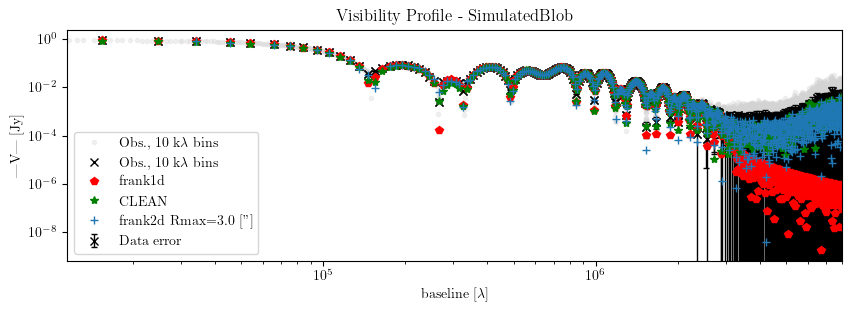

In [61]:
plt.figure(figsize=(10,3))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, np.abs(binned_vis0.V), c='lightgray',alpha=0.3, zorder=0,
                marker='.', ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))
plt.plot(q_input_d, np.abs(binning_data), c='black',
                marker='x', ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

plt.errorbar(q_input_d,  np.abs(binning_data), np.abs(binning_err), color='black',fmt='x', capsize=2, linewidth=1, zorder=1, label='Data error')


# frank1D ---------------------------------------------------------------------
plt.plot(q_input_d, np.abs(vis_model_f1d), color = 'red', ls ='None', marker='p',  label = r'frank1d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q_input_d, np.abs(vis_model_1d_c), color = 'green', ls ='None', marker='*',  label = r'CLEAN')

# frank2D -------------------------------------------------------------------
for i in range(len(vis_models_1d_f2d)):
    vis_model_1d_f2d = vis_models_1d_f2d[i]
    Rmax = frank2d_objects[i].Rmax
    plt.plot(q_input_d, np.abs(vis_model_1d_f2d), marker ='+', ls = 'None',label = r'frank2d Rmax=' + str(Rmax) + ' ["]')


plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
#plt.ylim(1e-5, 0)
plt.xlim(min_input, 8e6)
plt.title(f'Visibility Profile - {disk_name}')
plt.ylabel('|V| [Jy]', size = 10)
plt.legend(fontsize= 10, loc = 'best')
plt.show()

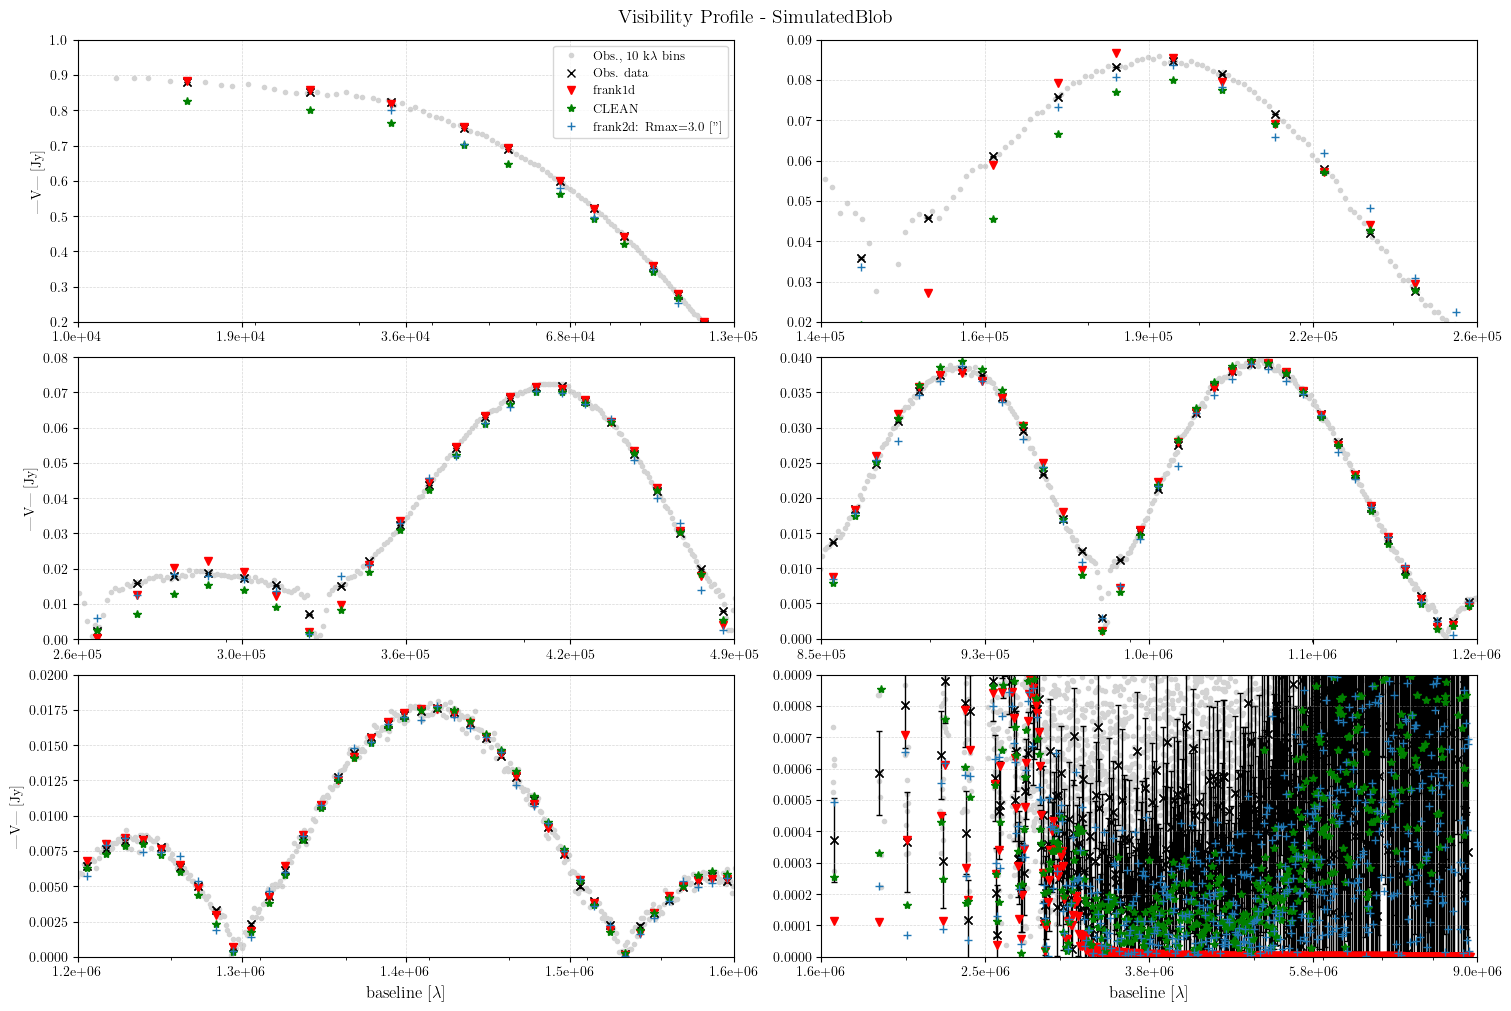

In [62]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Changed to 3 rows, 2 columns
fig, axes = plt.subplots(3, 2, figsize=(15, 10), constrained_layout=True)
fig.suptitle(f'Visibility Profile - {disk_name}', fontsize=14)

# Define X limits for each of the 6 plots (Row 1, Row 2, Row 3)
x_ranges = [
    [1e4, 1.3e5], [1.4e5, 2.6e5],  # Plot 0, Plot 1
    [2.6e5, 4.9e5],   [8.5e5, 1.2e6],    # Plot 2, Plot 3
    [1.2e6, 1.6e6],   [1.6e6, 9e6]     # Plot 4, Plot 5
]

# Define Y limits for each of the 6 plots
y_ranges = [
    [0.2, 1],      [0.02, 0.09],
    [-1e-4, 0.08], [-1e-4, 0.04],
    [0, 2e-2],     [0, 9e-4]
]

# Flatten axes to iterate linearly over the 3x2 grid
for i, (ax, x_lims, y_lims) in enumerate(zip(axes.flatten(), x_ranges, y_ranges)):
    
    ax.plot(binned_vis0.uv, np.abs(binned_vis0.V), c='lightgray', zorder=0, 
            marker='.', ls='None',
            label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))
    ax.plot(q_input_d, np.abs(binning_data), c='black',
            marker='x', ls='None', label='Obs. data')
    ax.errorbar(q_input_d, np.abs(binning_data), binning_err.real, 
                color='black', fmt='x', capsize=2, linewidth=1, zorder=1)

    ax.plot(q_input_d, np.abs(vis_model_f1d), color='red', ls='None', marker='v', label='frank1d')
    ax.plot(q_input_d, np.abs(vis_model_1d_c), color='green', ls='None', marker='*', label='CLEAN')

    for j in range(len(vis_models_1d_f2d)):
        vis_model_1d_f2d = vis_models_1d_f2d[j]
        Rmax = frank2d_objects[j].Rmax
        ax.plot(q_input_d, np.abs(vis_model_1d_f2d), ls='None', marker='+', label=f'frank2d: Rmax={Rmax} ["]')

    ax.set_xscale('log')
    ax.set_xlim(x_lims)

    if y_lims is not None:
        ax.set_ylim(y_lims)
        
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)

    custom_ticks = np.geomspace(x_lims[0], x_lims[1], 5)
    ax.set_xticks(custom_ticks)
    
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    
    ax.tick_params(axis='x', rotation=0)

    # Add legend only to the first plot
    if i == 0:
        ax.legend(fontsize=9, loc='upper right', frameon=True)
    
    # Add Y label only to the left column (indices 0, 2, 4)
    if i % 2 == 0:
        ax.set_ylabel('|V| [Jy]', size=10)

    # Add X label only to the bottom row (indices 4, 5)
    if i >= 4:
        ax.set_xlabel(r'baseline [$\lambda$]', fontsize=12)

plt.show()

##### Plot real vis

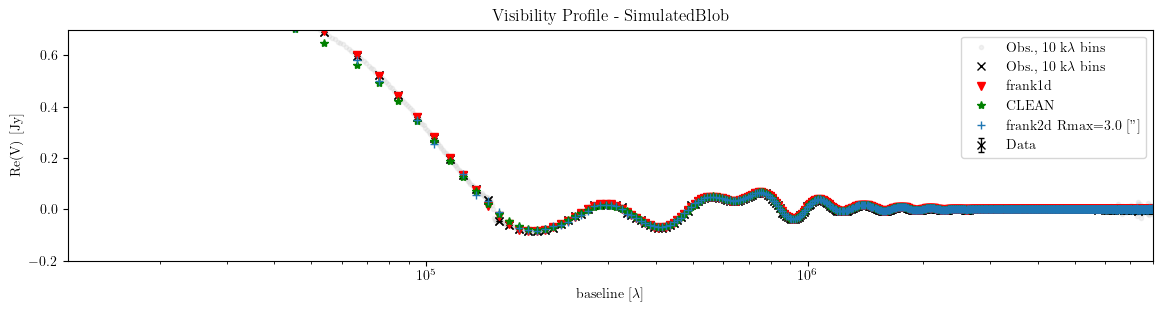

In [63]:
plt.figure(figsize=(14,3))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, binned_vis0.V.real, c='lightgray',alpha=0.3, zorder=0,
                marker='.', ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))
plt.plot(q_input_d, binning_data.real, c='black',
                marker='x', ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

plt.errorbar(q_input_d, binning_data.real, binning_err.real, color='black',fmt='x', capsize=2, linewidth=1, zorder=1, label='Data')


# frank1D ---------------------------------------------------------------------
plt.plot(q_input_d, vis_model_f1d.real, color = 'red', ls ='None', marker='v',  label = r'frank1d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q_input_d, vis_model_1d_c.real, color = 'green', ls ='None', marker='*',  label = r'CLEAN')

# frank2D -------------------------------------------------------------------
for i in range(len(vis_models_1d_f2d)):
    vis_model_1d_f2d = vis_models_1d_f2d[i]
    Rmax = frank2d_objects[i].Rmax
    plt.plot(q_input_d, vis_model_1d_f2d.real, marker ='+', ls = 'None',label = r'frank2d Rmax=' + str(Rmax) + ' ["]')



plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.ylim(-0.2, 0.7)
plt.xlim(min_input, 8e6)
plt.title(f'Visibility Profile - {disk_name}')
plt.ylabel('Re(V) [Jy]', size = 10)
plt.legend(fontsize= 10, loc = 'upper right')
plt.show()

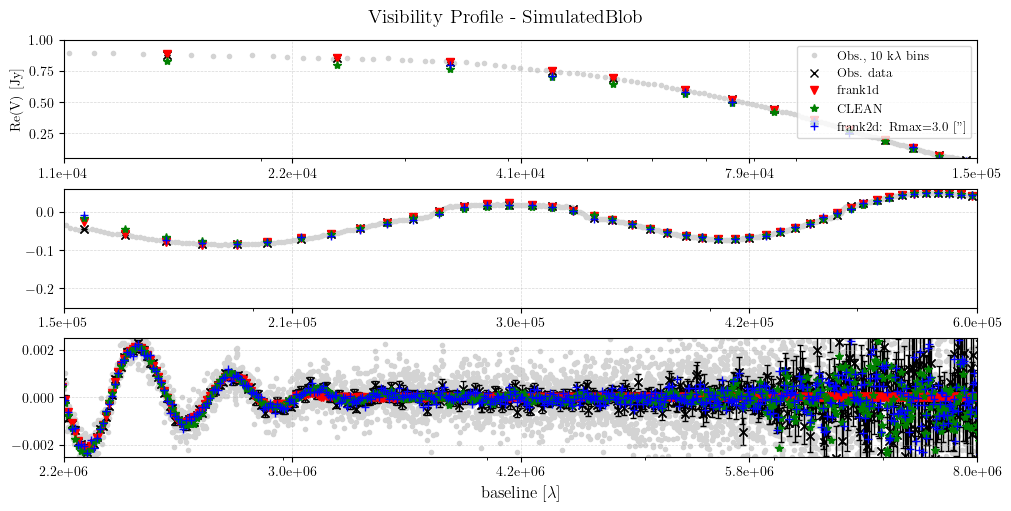

In [64]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(10, 5), constrained_layout=True)
fig.suptitle(f'Visibility Profile - {disk_name}', fontsize=14)

x_ranges = [
    [min_input, 1.5e5],
    [1.5e5, 6e5],
    [2.2e6, 8e6]
]

y_ranges = [
    [0.05, 1],
    [-0.25, 0.06],
    [-0.0025, 0.0025]
]

for i, (ax, x_lims, y_lims) in enumerate(zip(axes, x_ranges, y_ranges)):
    
    ax.plot(binned_vis0.uv, binned_vis0.V.real, c='lightgray', zorder = 0, 
            marker='.', ls='None',
            label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))
    ax.plot(q_input_d, binning_data.real, c='black',
            marker='x', ls='None', label='Obs. data')
    ax.errorbar(q_input_d, binning_data.real, binning_err.real, 
                color='black', fmt='x', capsize=2, linewidth=1, zorder=1)

    ax.plot(q_input_d, vis_model_f1d.real, color='red', ls='None', marker='v', label='frank1d')
    ax.plot(q_input_d, vis_model_1d_c.real, color='green', ls='None', marker='*', label='CLEAN')
    
    for j in range(len(vis_models_1d_f2d)):
        vis_model_1d_f2d = vis_models_1d_f2d[j]
        Rmax = frank2d_objects[j].Rmax
        ax.plot(q_input_d, vis_model_1d_f2d.real, ls='None', color = 'blue', marker='+', label=f'frank2d: Rmax={Rmax} ["]')

    ax.set_xscale('log')
    ax.set_xlim(x_lims)
    
    if y_lims is not None:
        ax.set_ylim(y_lims)
        
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)

    custom_ticks = np.geomspace(x_lims[0], x_lims[1], 5)
    ax.set_xticks(custom_ticks)
    
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    
    ax.tick_params(axis='x', rotation=0)

    if i == 0:
        ax.legend(fontsize=9, loc='upper right', frameon=True)
        ax.set_ylabel('Re(V) [Jy]', size=10)

axes[-1].set_xlabel(r'baseline [$\lambda$]', fontsize=12)

plt.show()

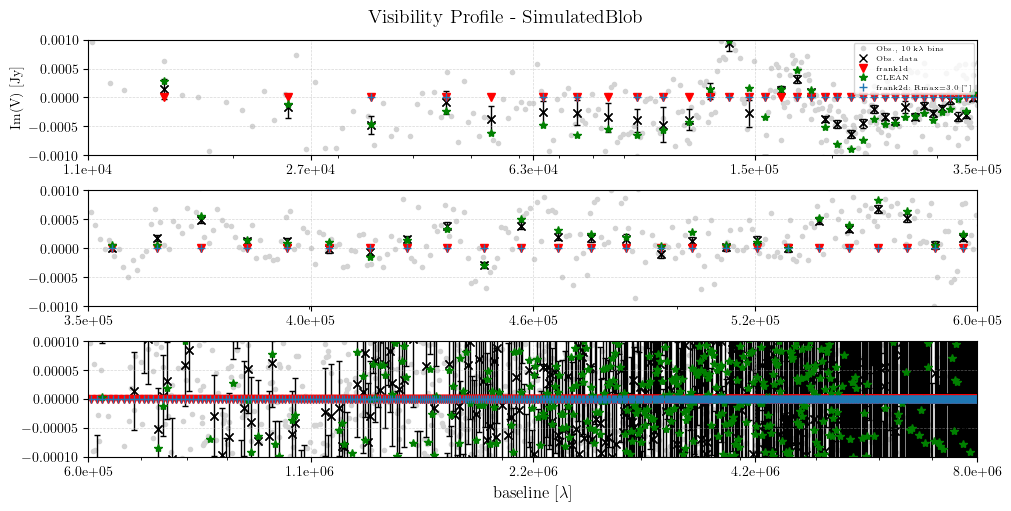

In [65]:
import matplotlib.ticker as ticker

fig, axes = plt.subplots(3, 1, figsize=(10, 5), constrained_layout=True)
fig.suptitle(f'Visibility Profile - {disk_name}', fontsize=14)

x_ranges = [
    [min_input , 3.5e5],
    [3.5e5, 6e5],
    [6e5, 8e6]
]

y_ranges = [
    [-1e-3, 1e-3],
    [-1e-3, 1e-3],
    [-1e-4, 1e-4]
]

for i, (ax, x_lims, y_lims) in enumerate(zip(axes, x_ranges, y_ranges)):

    ax.plot(binned_vis0.uv, binned_vis0.V.imag, c='lightgray', zorder = 0, 
            marker='.', ls='None',
            label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))
    ax.plot(q_input_d, binning_data.imag, c='black',
            marker='x', ls='None', label='Obs. data')
    ax.errorbar(q_input_d, binning_data.imag, binning_err.real, 
                color='black', fmt='x', capsize=2, linewidth=1, zorder=1)

    ax.plot(q_input_d, vis_model_f1d.imag, color='red', ls='None', marker='v', label='frank1d')
    ax.plot(q_input_d, vis_model_1d_c.imag, color='green', ls='None', marker='*', label='CLEAN')
    
    for j in range(len(vis_models_1d_f2d)):
        vis_model_1d_f2d = vis_models_1d_f2d[j]
        Rmax = frank2d_objects[j].Rmax
        ax.plot(q_input_d, vis_model_1d_f2d.imag, ls='None', marker='+', label=f'frank2d: Rmax={Rmax} ["]')

    ax.set_xscale('log')
    ax.set_xlim(x_lims)
    
    if y_lims is not None:
        ax.set_ylim(y_lims)
        
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)

    custom_ticks = np.geomspace(x_lims[0], x_lims[1], 5)
    ax.set_xticks(custom_ticks)
    
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    
    ax.tick_params(axis='x', rotation=0)

    if i == 0:
        ax.legend(fontsize=5, loc='upper right', frameon=True)
        ax.set_ylabel('Im(V) [Jy]', size=10)

axes[-1].set_xlabel(r'baseline [$\lambda$]', fontsize=12)

plt.show()

#### Calculate the residuals

In [68]:
ground_sigma = binned_vis1.error
ground = binned_vis1.V

In [69]:
residual_clean_data = ground - vis_model_1d_c

In [70]:
residual_f1d_data  =  ground - vis_model_f1d

In [71]:
q_max = 4e6

In [72]:
residual_f2d_data  =  ground - vis_model_1d_f2d

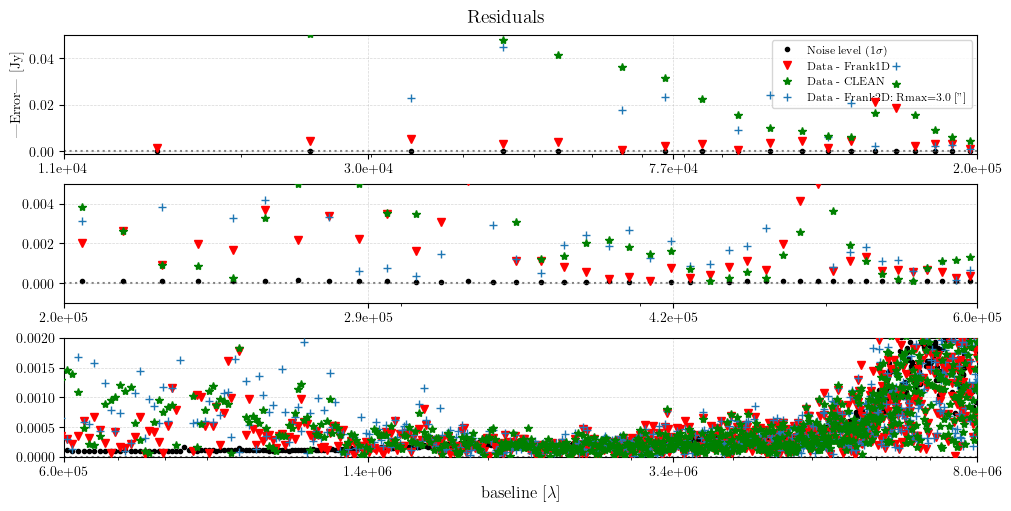

In [73]:
fig, axes = plt.subplots(3, 1, figsize=(10, 5), constrained_layout=True)
fig.suptitle('Residuals', fontsize=14)

x_ranges = [
    [min_input, 2e5],
    [2e5, 6e5],
    [6e5, 8e6]
]

y_ranges = [
    [-0.001, 0.05],
    [-0.001, 0.005],
    [-0, 0.002]
]

for i, (ax, x_lims, y_lims) in enumerate(zip(axes, x_ranges, y_ranges)):
    
    ax.plot(q_input_d, np.abs(ground_sigma), color='black', ls='None', 
            marker='.', zorder=1, label=r'Noise level (1$\sigma$)')
        
    ax.plot(q_input_d, np.abs(residual_f1d_data), color='red', ls='None',
            marker='v', zorder=9, label=r'Data - Frank1D')

    ax.plot(q_input_d, np.abs(residual_clean_data), color='green', ls='None', 
            marker='*', zorder=10, label=r'Data - CLEAN')
    
    for j in range(len(vis_models_1d_f2d)):
        vis_model_1d_f2d = vis_models_1d_f2d[j]
        residual_f2d_data = ground - vis_model_1d_f2d
        ax.plot(q_input_d, np.abs(residual_f2d_data), ls='None',
                marker='+', zorder=9, label=f'Data - Frank2D: Rmax={frank2d_objects[j].Rmax} ["]')

    ax.axhline(0.0, color='gray', ls=':', zorder=0)
    ax.set_xscale('log')
    ax.set_xlim(x_lims)
    
    if y_lims is not None:
        ax.set_ylim(y_lims)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)

    custom_ticks = np.geomspace(x_lims[0], x_lims[1], 4)
    ax.set_xticks(custom_ticks)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.tick_params(axis='x', rotation=0)

    if i == 0:
        ax.legend(fontsize=8, loc='upper right')
        ax.set_ylabel('|Error| [Jy]', size=10)

axes[-1].set_xlabel(r'baseline [$\lambda$]', fontsize=12)

plt.show()

In [74]:
residual_clean_data_sigma_re = residual_clean_data.real/ ground_sigma.data.real
residual_f1d_data_sigma_re  =  residual_f1d_data.real / ground_sigma.data.real

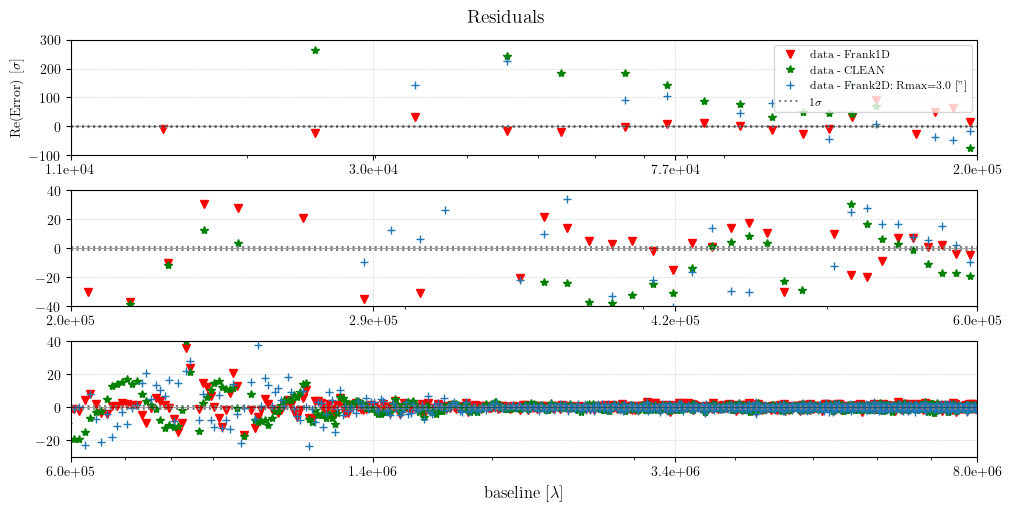

In [75]:
fig, axes = plt.subplots(3, 1, figsize=(10, 5), constrained_layout=True)
fig.suptitle('Residuals', fontsize=14)

x_ranges = [
    [min_input, 2e5],
    [2e5, 6e5],
    [6e5, 8e6]
]

y_ranges = [
    [-100, 300],
    [-40, 40],
    [-30, 40]
]

for i, (ax, x_lims, y_lims) in enumerate(zip(axes, x_ranges, y_ranges)):

    ax.plot(q_input_d, residual_f1d_data_sigma_re, color='red', ls='None',
            marker='v', label=r'data - Frank1D')
    
    ax.plot(q_input_d, residual_clean_data_sigma_re, color='green', ls='None', 
            marker='*', label=r'data - CLEAN')
    for j in range(len(vis_models_1d_f2d)):
        vis_model_1d_f2d = vis_models_1d_f2d[j]
        residual_f2d_data = ground - vis_model_1d_f2d
        residual_f2d_data_sigma_re = residual_f2d_data.real / ground_sigma.data.real
        ax.plot(q_input_d, residual_f2d_data_sigma_re, ls='None',
                marker='+', label=f'data - Frank2D: Rmax={frank2d_objects[j].Rmax} ["]')

    ax.axhline(1, color='gray', ls=':', label=r'1$\sigma$')
    ax.axhline(-1, color='gray', ls=':')
    ax.axhline(0, color='black', alpha=0.3, linewidth=0.8)

    ax.set_xscale('log')
    ax.set_xlim(x_lims)
    
    if y_lims is not None:
        ax.set_ylim(y_lims)

    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)

    custom_ticks = np.geomspace(x_lims[0], x_lims[1], 4)
    ax.set_xticks(custom_ticks)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    
    ax.tick_params(axis='x', rotation=0)

    if i == 0:
        ax.legend(fontsize=8, loc='upper right', frameon=True)
        ax.set_ylabel(r'Re(Error) [$\sigma$]', size=10)

axes[-1].set_xlabel(r'baseline [$\lambda$]', fontsize=12)

plt.show()

In [76]:
residual_clean_data_sigma_imag = residual_clean_data.imag/ ground_sigma.data.imag
residual_f1d_data_sigma_imag  =  residual_f1d_data.imag / ground_sigma.data.imag

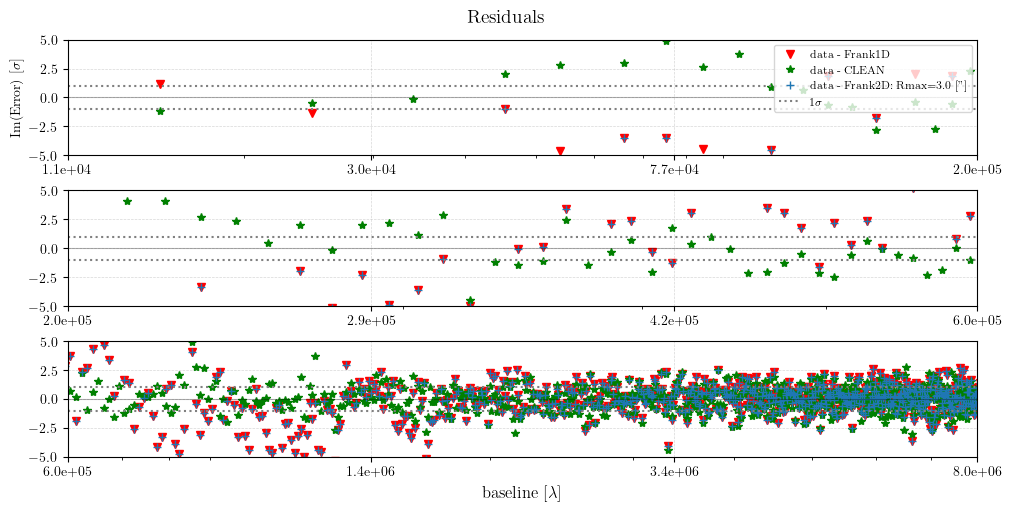

In [77]:
fig, axes = plt.subplots(3, 1, figsize=(10, 5), constrained_layout=True)
fig.suptitle('Residuals', fontsize=14)

x_ranges = [
    [min_input, 2e5],
    [2e5, 6e5],
    [6e5, 8e6]
]

y_ranges = [
    [-5, 5],
    [-5, 5],
    [-5, 5]
]

for i, (ax, x_lims, y_lims) in enumerate(zip(axes, x_ranges, y_ranges)):
    
    ax.plot(q_input_d, residual_f1d_data_sigma_imag, color='red', ls='None',
            marker='v', label=r'data - Frank1D')
    
    ax.plot(q_input_d, residual_clean_data_sigma_imag, color='green', ls='None', 
            marker='*', label=r'data - CLEAN')

    for j in range(len(vis_models_1d_f2d)):
        vis_model_1d_f2d = vis_models_1d_f2d[j]
        residual_f2d_data = ground - vis_model_1d_f2d
        residual_f2d_data_sigma_imag = residual_f2d_data.imag / ground_sigma.data.imag
        ax.plot(q_input_d, residual_f2d_data_sigma_imag, ls='None', 
            marker='+', label=r'data - Frank2D: Rmax=' + str(frank2d_objects[j].Rmax) + ' ["]')
        

    ax.axhline(1, color='gray', ls=':', label=r'1$\sigma$')
    ax.axhline(-1, color='gray', ls=':')
    ax.axhline(0, color='black', alpha=0.3, linewidth=0.8)

    ax.set_xscale('log')
    ax.set_xlim(x_lims)
    
    if y_lims is not None:
        ax.set_ylim(y_lims)

    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)

    custom_ticks = np.geomspace(x_lims[0], x_lims[1], 4)
    ax.set_xticks(custom_ticks)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    
    ax.tick_params(axis='x', rotation=0)

    if i == 0:
        ax.legend(fontsize=8, loc='upper right', frameon=True)
        ax.set_ylabel(r'Im(Error) [$\sigma$]', size=10)

axes[-1].set_xlabel(r'baseline [$\lambda$]', fontsize=12)

plt.show()

### Times and flux

In [ ]:
for i in frank_objects:
    

## 2D


* We compare with FFT(CLEAN .model)
* By now, we'll use imsize = 3000, rout = 2,4 -> cellsize = 0.0016, but in the future we plan rout = 2,4 and imsize = 1600 -> REDO CLEAN!

In [364]:
imsize = 3000

In [365]:
rmax = Rmax
rmax


3.5999999999999996

In [272]:
frank2d2 = Frank2D(imsize, rmax)

In [273]:
start_time = time.time()
frank2d2.fit(data = uvtable, kernel_params = best, rtol = 1e-8 )

end_time = time.time()
print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with N = {imsize} took {end_time - start_time} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -1.3620942401288272, 'c': 4681.245509195992, 'l': 72454.18892316935}
===>  Creating sparse linear system...
        +  Kernel = 0.21  min |  12.73 seconds
        +  Building system = 0.22  min |  13.14 seconds
===>  Solving linear system...
      .... iteration  0 :   actual tol  2.14e+08  versus  2.14e+00
      .... iteration  10 :   actual tol  9.95e+06  versus  2.14e+00
      .... iteration  20 :   actual tol  9.50e+06  versus  2.14e+00
      .... iteration  30 :   actual tol  1.01e+07  versus  2.14e+00
      .... iteration  40 :   actual tol  7.48e+06  versus  2.14e+00
      .... iteration  50 :   actual tol  6.41e+06  versus  2.14e+00
      .... iteration  60 :   actual tol  4.73e+06  versus  2.14e+00
      .... iteration  70 :   actual tol  4.36e+06  versus  2.14e+00
      .... iteration  80 :   actual tol  3.73e+06  versus  2.14e+00
      .... iteration  90 :   actual tol  3.25e+06

KeyboardInterrupt: 

In [ ]:
cell =  2*rmax/imsize
cell

0.0007999999999999999

### Frank2d Vis Map

In [ ]:
vis2d_f2d = frank2d2.visibility_model

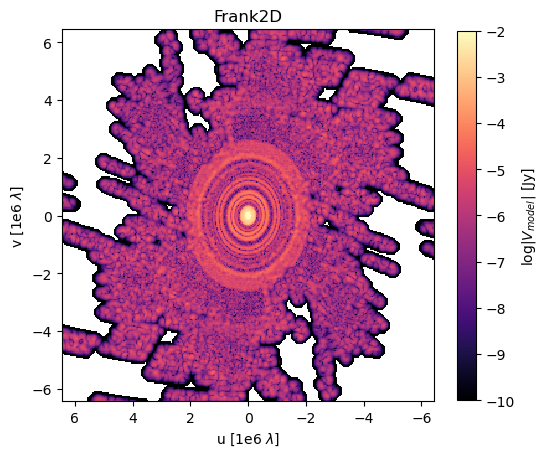

In [ ]:
u_f2d, v_f2d = -frank2d2.u_grid.reshape(imsize,imsize), -frank2d2.v_grid.reshape(imsize,imsize)

plt.figure(figsize = (6, 6))
plt.pcolormesh( u_f2d/1e6, v_f2d/1e6,
                np.log(np.abs(vis2d_f2d.reshape(imsize,imsize))),
                cmap="magma",
                vmin=-10, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title("Frank2D")
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'log|$V_{model}$| [Jy]', size=10)
plt.xlim(u_f2d.max()/1e7, u_f2d.min()/1e7)
plt.ylim(v_f2d.min()/1e7, v_f2d.max()/1e7)
plt.gca().set_aspect(1)
plt.show()

### CLEAN .model

In [ ]:
from astropy.io import fits
dir_  = "../../data/"

disk = "CLEAN_AS209_dotmodel_fov9_imsize3000.fits"

fits_name = dir_ + disk
hdul = fits.open(fits_name)

In [ ]:
import matplotlib.colors as colors

In [ ]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

In [ ]:
hdr = hdul[0].header
data = hdul[0].data 

In [ ]:
# beam
bmaj = hdr.get('BMAJ') # degrees
#bmaj_arsec = bmaj * 3600 # arcseconds
#bmin = hdr.get('BMIN')
#bmin_arsec = bmin * 3600 # arcseconds
bpa = hdr.get('BPA')

In [ ]:
w = WCS(hdr)

In [ ]:
data_squeezed = np.squeeze(data)   # (3000,3000) si los ejes 1 desaparecen
print("shape original:", data.shape, "-> squeezed:", data_squeezed.shape)

shape original: (1, 1, 3000, 3000) -> squeezed: (3000, 3000)


In [ ]:
data = data_squeezed

In [ ]:
if data.ndim == 3:
    # asumo (nz, ny, nx)
    nz, ny, nx = data.shape
    if channel_index is None:
        # elige el canal central por defecto
        ci = nz // 2
    else:
        ci = int(channel_index)
    img = data[ci, :, :].copy()
    # build a WCS for the 2D plane (drop the spectral axis)
    w2 = w.celestial  # WCS restringido a ejes celestes (RA/Dec)
else:
    ny, nx = data.shape
    img = data.copy()
    w2 = w.celestial

In [ ]:
# pixel coordinates
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y)

# wcs expects pixel coords in 1-based -> use wcs_pix2world with origin=0
ra_deg, dec_deg = w2.wcs_pix2world(xx, yy, 0)  # devuelve en grados

# reference coordinate (CRVAL)
crval_ra = w2.wcs.crval[0]
crval_dec = w2.wcs.crval[1]
refcoord = SkyCoord(crval_ra*u.deg, crval_dec*u.deg)

# compute offsets in arcsec from reference coordinate
coords = SkyCoord(ra_deg*u.deg, dec_deg*u.deg)
lon_off, lat_off = coords.spherical_offsets_to(refcoord)
# convertir a arcsec, y poner el eje x como RA offset (positivo hacia el Este)
ra_off_arcsec = -lon_off.to(u.arcsec).value
dec_off_arcsec = lat_off.to(u.arcsec).value

# extent of the image in arcsec (for imshow)
xmin = ra_off_arcsec.min()
xmax = ra_off_arcsec.max()
ymin = dec_off_arcsec.min()
ymax = dec_off_arcsec.max()

# we need to flip the y axis to match the imshow convention
img = np.flipud(img)



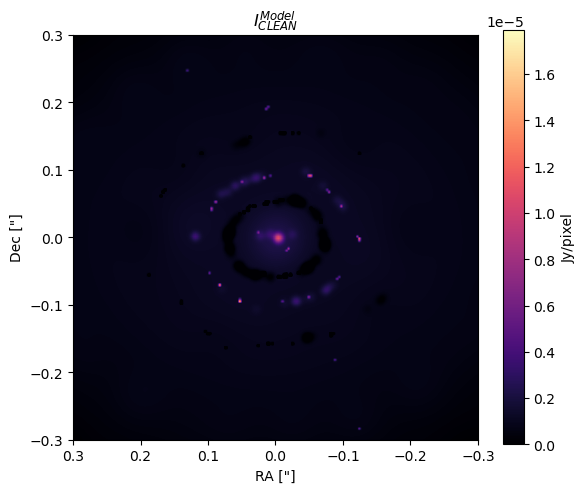

In [ ]:
plt.figure(figsize=(6,5))
norm = colors.PowerNorm(gamma=1, vmin=0, vmax = img.max())
ax = plt.gca()
im = ax.imshow(
    img,
    extent=[xmin, xmax, ymin, ymax],
    aspect='equal',
    cmap='magma',
    norm=norm,
)
ax.set_xlabel('RA ["]')
ax.set_ylabel('Dec ["]')
ax.set_title(r'$I^{Model}_{CLEAN}$')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(hdr.get('BUNIT', 'Intensity'))
plt.xlim(0.3, -0.3)
plt.ylim(-0.3, 0.3)
ax.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
# arcsecs per pixel
ra_off_arcsec[0][1] -ra_off_arcsec[0][0]

-0.0016000046066801943

In [ ]:
# img comes without the beam convolutded
# I_clean_model =  np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis_model_c_grid))).real/(frank2d3.FT._dx * frank2d3.FT._dy)
vis_clean = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img)))

In [ ]:
vis_clean.shape

(3000, 3000)

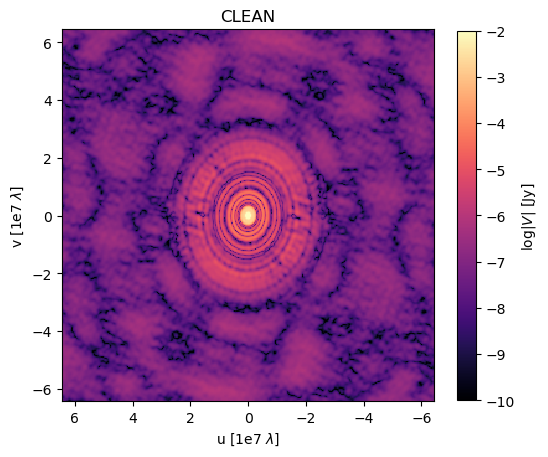

In [ ]:
plt.figure(figsize = (6, 6))
plt.pcolormesh( u_f2d/1e6, v_f2d/1e6,
            np.log(np.abs(vis_clean.reshape(imsize, imsize))),
            cmap="magma",
            vmin=-10, vmax=-2)
plt.xlabel(r'u [1e7 $\lambda$]')
plt.ylabel(r'v [1e7 $\lambda$]')
plt.title("CLEAN")
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'log|$V$| [Jy]', size=10)
plt.xlim(u_f2d.max()/1e7, u_f2d.min()/1e7)
plt.ylim(v_f2d.min()/1e7, v_f2d.max()/1e7)
plt.gca().set_aspect(1)
plt.show()

### Difference

In [ ]:
diff = (vis2d_f2d - vis_clean)/vis_clean

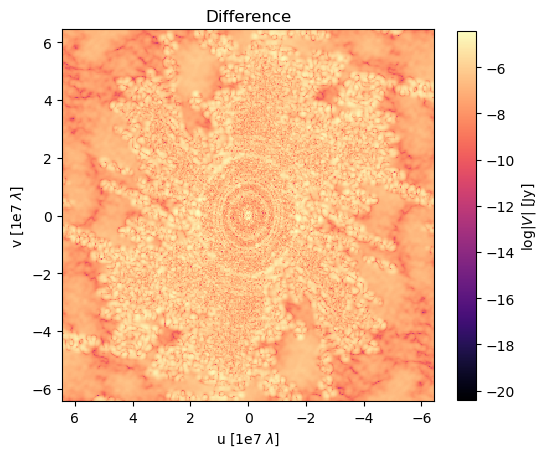

In [ ]:
plt.figure(figsize = (6, 6))
plt.pcolormesh( u_f2d/1e6, v_f2d/1e6,
            np.log(np.abs((diff).reshape(imsize, imsize))),
            cmap="magma")
plt.xlabel(r'u [1e7 $\lambda$]')
plt.ylabel(r'v [1e7 $\lambda$]')
plt.title("Difference")
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'log|$V$| [Jy]', size=10)
plt.xlim(u_f2d.max()/1e7, u_f2d.min()/1e7)
plt.ylim(v_f2d.min()/1e7, v_f2d.max()/1e7)
plt.gca().set_aspect(1)
plt.show()